In [ ]:
# Basic libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ML tools
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.impute import SimpleImputer

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier


In [ ]:
from google.colab import files
uploaded = files.upload()


Saving diabetes+130-us+hospitals+for+years+1999-2008.zip to diabetes+130-us+hospitals+for+years+1999-2008.zip


In [ ]:
import zipfile

zip_file = list(uploaded.keys())[0]   # Automatically gets your uploaded file name

with zipfile.ZipFile(zip_file, 'r') as z:
    z.extractall(".")   # Extract to current directory



In [ ]:
import os

os.listdir(".")



['.config',
 'diabetes+130-us+hospitals+for+years+1999-2008.zip',
 'diabetic_data.csv',
 'IDS_mapping.csv',
 'sample_data']

In [ ]:
import pandas as pd

df = pd.read_csv("diabetic_data.csv")
df.head()


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [ ]:
import pandas as pd

df = pd.read_csv("diabetic_data.csv")
df.head()


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [ ]:
df.shape


(101766, 50)

In [ ]:
df.columns


Index(['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'weight',
       'admission_type_id', 'discharge_disposition_id', 'admission_source_id',
       'time_in_hospital', 'payer_code', 'medical_specialty',
       'num_lab_procedures', 'num_procedures', 'num_medications',
       'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1',
       'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult',
       'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
       'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide',
       'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone',
       'tolazamide', 'examide', 'citoglipton', 'insulin',
       'glyburide-metformin', 'glipizide-metformin',
       'glimepiride-pioglitazone', 'metformin-rosiglitazone',
       'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted'],
      dtype='object')

In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      101766 non-null  object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    101766 non-null  object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                101766 non-null  object
 11  medical_specialty         101766 non-null  object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non-null  int64 
 14  num_

In [ ]:
df['readmitted'].value_counts()


,count
readmitted,
NO,54864
>30,35545
<30,11357


In [ ]:
(df == '?').sum()


,0
encounter_id,0
patient_nbr,0
race,2273
gender,0
age,0
weight,98569
admission_type_id,0
discharge_disposition_id,0
admission_source_id,0
time_in_hospital,0


In [ ]:
import numpy as np

df = df.replace("?", np.nan)


In [ ]:
df.isnull().sum()


,0
encounter_id,0
patient_nbr,0
race,2273
gender,0
age,0
weight,98569
admission_type_id,0
discharge_disposition_id,0
admission_source_id,0
time_in_hospital,0


In [ ]:
df.isnull().mean().sort_values(ascending=False)


,0
weight,0.968585
max_glu_serum,0.947468
A1Cresult,0.832773
medical_specialty,0.490822
payer_code,0.395574
race,0.022336
diag_3,0.013983
diag_2,0.003518
diag_1,0.000206
patient_nbr,0.000000


In [ ]:
df.isnull().mean().sort_values(ascending=False)


,0
weight,0.968585
max_glu_serum,0.947468
A1Cresult,0.832773
medical_specialty,0.490822
payer_code,0.395574
race,0.022336
diag_3,0.013983
diag_2,0.003518
diag_1,0.000206
patient_nbr,0.000000


In [ ]:
df = df.drop(['encounter_id', 'patient_nbr'], axis=1)


In [ ]:
df['readmitted'] = df['readmitted'].replace({
    'NO': 0,
    '>30': 0,
    '<30': 1
})


/tmp/ipython-input-2743935470.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['readmitted'] = df['readmitted'].replace({


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline


In [ ]:
# Check missing values
df.isnull().sum()

# Replace "?" with NaN (the dataset uses ? instead of missing)
df = df.replace("?", pd.NA)

# Drop columns with extremely high missing values
threshold = 0.60   # drop columns with >60% missing
df = df.dropna(axis=1, thresh=len(df)*threshold)

# For remaining missing values, fill based on type
for col in df.columns:
    if df[col].dtype == "object":   # categorical
        df[col] = df[col].fillna(df[col].mode()[0])
    else:
        df[col] = df[col].fillna(df[col].median())


In [ ]:
# Convert all categorical values to lowercase
df = df.apply(lambda col: col.astype(str).str.lower()
              if col.dtype == 'object' else col)


In [ ]:
from sklearn.preprocessing import LabelEncoder

target = "readmitted"
le = LabelEncoder()
df[target] = le.fit_transform(df[target])


In [ ]:
X = df.drop("readmitted", axis=1)
y = df["readmitted"]


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

categorical_cols = X.select_dtypes(include=["object"]).columns
numeric_cols = X.select_dtypes(include=["int64", "float64"]).columns

preprocessor = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown='ignore'), categorical_cols),
    ("num", StandardScaler(), numeric_cols)
])


In [ ]:
from sklearn.feature_selection import SelectKBest, chi2

feature_selector = SelectKBest(chi2, k=50)  # select top 50 features


In [ ]:
from sklearn.pipeline import Pipeline

pipeline = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("feature_select", feature_selector)
])


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_processed, y, test_size=0.2, random_state=42
)

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)


Training set shape: (81412, 50)
Test set shape: (20354, 50)


In [ ]:
from sklearn.linear_model import LogisticRegression

# Create and train model
lr_model = LogisticRegression(max_iter=500, random_state=42)
lr_model.fit(X_train, y_train)

# Predict
y_pred_lr = lr_model.predict(X_test)


In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Predict
y_pred_rf = rf_model.predict(X_test)


In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score

# Logistic Regression
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Logistic Regression F1-score:", f1_score(y_test, y_pred_lr, average='weighted'))
print("Logistic Regression Confusion Matrix:\n", confusion_matrix(y_test, y_pred_lr))

# Random Forest
print("\nRandom Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Random Forest F1-score:", f1_score(y_test, y_pred_rf, average='weighted'))
print("Random Forest Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))


Logistic Regression Accuracy: 0.8873440110052078
Logistic Regression F1-score: 0.8373468119196227
Logistic Regression Confusion Matrix:
 [[18033    36]
 [ 2257    28]]

Random Forest Accuracy: 0.8873440110052078
Random Forest F1-score: 0.8366173790302242
Random Forest Confusion Matrix:
 [[18041    28]
 [ 2265    20]]


In [ ]:
X_train_small, _, y_train_small, _ = train_test_split(X_train, y_train, train_size=20000, random_state=42)


In [ ]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10]
}

random_search = RandomizedSearchCV(rf_model, param_distributions=param_dist,
                                   n_iter=10, cv=3, scoring='f1_weighted', n_jobs=-1, random_state=42)
random_search.fit(X_train_small, y_train_small)


RandomizedSearchCV(cv=3, estimator=RandomForestClassifier(random_state=42),
                   n_jobs=-1,
                   param_distributions={'max_depth': [None, 10, 20, 30],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [100, 200, 300]},
                   random_state=42, scoring='f1_weighted')

In [ ]:
from sklearn.metrics import accuracy_score

print("LR Accuracy:", accuracy_score(y_test, y_pred_lr))
print("RF Accuracy:", accuracy_score(y_test, y_pred_rf))


LR Accuracy: 0.8873440110052078
RF Accuracy: 0.8873440110052078


In [ ]:
from sklearn.metrics import f1_score

print("LR F1:", f1_score(y_test, y_pred_lr, average='weighted'))
print("RF F1:", f1_score(y_test, y_pred_rf, average='weighted'))


LR F1: 0.8373468119196227
RF F1: 0.8366173790302242


In [ ]:
from sklearn.metrics import confusion_matrix

print("LR Confusion Matrix:\n", confusion_matrix(y_test, y_pred_lr))
print("RF Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))


LR Confusion Matrix:
 [[18033    36]
 [ 2257    28]]
RF Confusion Matrix:
 [[18041    28]
 [ 2265    20]]


In [ ]:
from sklearn.metrics import classification_report

print("LR Report:\n", classification_report(y_test, y_pred_lr))
print("RF Report:\n", classification_report(y_test, y_pred_rf))


LR Report:
               precision    recall  f1-score   support

           0       0.89      1.00      0.94     18069
           1       0.44      0.01      0.02      2285

    accuracy                           0.89     20354
   macro avg       0.66      0.51      0.48     20354
weighted avg       0.84      0.89      0.84     20354

RF Report:
               precision    recall  f1-score   support

           0       0.89      1.00      0.94     18069
           1       0.42      0.01      0.02      2285

    accuracy                           0.89     20354
   macro avg       0.65      0.50      0.48     20354
weighted avg       0.84      0.89      0.84     20354



=== Logistic Regression ===
Accuracy: 0.6635550751694999
F1-score (weighted): 0.7235363030958567

Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.68      0.78     18069
           1       0.17      0.52      0.26      2285

    accuracy                           0.66     20354
   macro avg       0.54      0.60      0.52     20354
weighted avg       0.83      0.66      0.72     20354



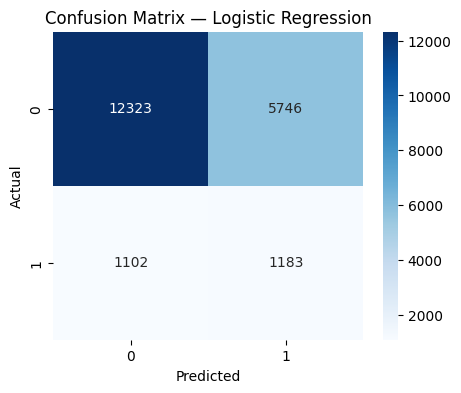

=== Random Forest ===
Accuracy: 0.8873440110052078
F1-score (weighted): 0.8358775479541698

Classification Report:
               precision    recall  f1-score   support

           0       0.89      1.00      0.94     18069
           1       0.38      0.01      0.01      2285

    accuracy                           0.89     20354
   macro avg       0.63      0.50      0.48     20354
weighted avg       0.83      0.89      0.84     20354



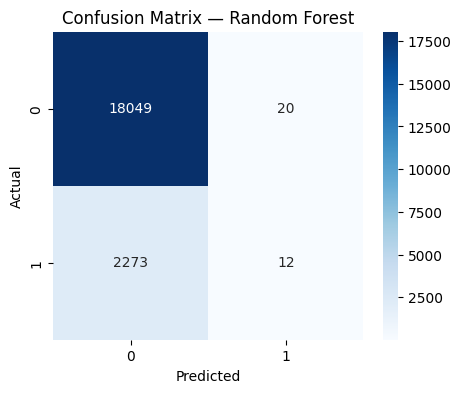


=== Model Comparison ===
                 Model  Accuracy  F1-score (weighted)
0  Logistic Regression  0.663555             0.723536
1        Random Forest  0.887344             0.835878


In [ ]:
# 1️⃣ Import metrics and plotting tools
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 2️⃣ Retrain models with class imbalance handled
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Logistic Regression with class_weight
lr_model = LogisticRegression(max_iter=500, random_state=42, class_weight='balanced')
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)

# Random Forest with class_weight
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

# 3️⃣ Evaluation metrics
def evaluate_model(y_true, y_pred, model_name):
    print(f"=== {model_name} ===")
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("F1-score (weighted):", f1_score(y_true, y_pred, average='weighted'))
    print("\nClassification Report:\n", classification_report(y_true, y_pred))

    # Confusion matrix plot
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"Confusion Matrix — {model_name}")
    plt.show()

# Evaluate both models
evaluate_model(y_test, y_pred_lr, "Logistic Regression")
evaluate_model(y_test, y_pred_rf, "Random Forest")

# 4️⃣ Comparison table
comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [accuracy_score(y_test, y_pred_lr), accuracy_score(y_test, y_pred_rf)],
    "F1-score (weighted)": [f1_score(y_test, y_pred_lr, average='weighted'),
                            f1_score(y_test, y_pred_rf, average='weighted')]
})
print("\n=== Model Comparison ===")
print(comparison)




In [ ]:
from google.colab import files
uploaded = files.upload()



Saving diabetes+130-us+hospitals+for+years+1999-2008.zip to diabetes+130-us+hospitals+for+years+1999-2008.zip


In [ ]:
import zipfile

zip_file = list(uploaded.keys())[0]   # Automatically gets your uploaded file name

with zipfile.ZipFile(zip_file, 'r') as z:
    z.extractall(".")   # Extract to current directory



In [ ]:
import os

os.listdir(".")


['.config',
 'diabetes+130-us+hospitals+for+years+1999-2008.zip',
 'diabetic_data.csv',
 'IDS_mapping.csv',
 'sample_data']

In [ ]:
who


files	 os	 pd	 plt	 uploaded	 z	 zip_file	 zipfile	 


In [ ]:
from google.colab import files
uploaded = files.upload()


Saving diabetes+130-us+hospitals+for+years+1999-2008.zip to diabetes+130-us+hospitals+for+years+1999-2008 (1).zip


In [ ]:
import zipfile

zip_file = list(uploaded.keys())[0]   # Automatically gets your uploaded file name

with zipfile.ZipFile(zip_file, 'r') as z:
    z.extractall(".")   # Extract to current directory


In [ ]:
import os

os.listdir(".")

['.config',
 'diabetes+130-us+hospitals+for+years+1999-2008.zip',
 'diabetes+130-us+hospitals+for+years+1999-2008 (1).zip',
 'diabetic_data.csv',
 'IDS_mapping.csv',
 'sample_data']

In [ ]:
import pandas as pd

df = pd.read_csv("diabetic_data.csv")
df.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [ ]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = df.select_dtypes(include=['object']).columns

numeric_cols, categorical_cols


(Index(['encounter_id', 'patient_nbr', 'admission_type_id',
        'discharge_disposition_id', 'admission_source_id', 'time_in_hospital',
        'num_lab_procedures', 'num_procedures', 'num_medications',
        'number_outpatient', 'number_emergency', 'number_inpatient',
        'number_diagnoses'],
       dtype='object'),
 Index(['race', 'gender', 'age', 'weight', 'payer_code', 'medical_specialty',
        'diag_1', 'diag_2', 'diag_3', 'max_glu_serum', 'A1Cresult', 'metformin',
        'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride',
        'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide',
        'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone',
        'tolazamide', 'examide', 'citoglipton', 'insulin',
        'glyburide-metformin', 'glipizide-metformin',
        'glimepiride-pioglitazone', 'metformin-rosiglitazone',
        'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted'],
       dtype='object'))

<Figure size 1500x1200 with 0 Axes>

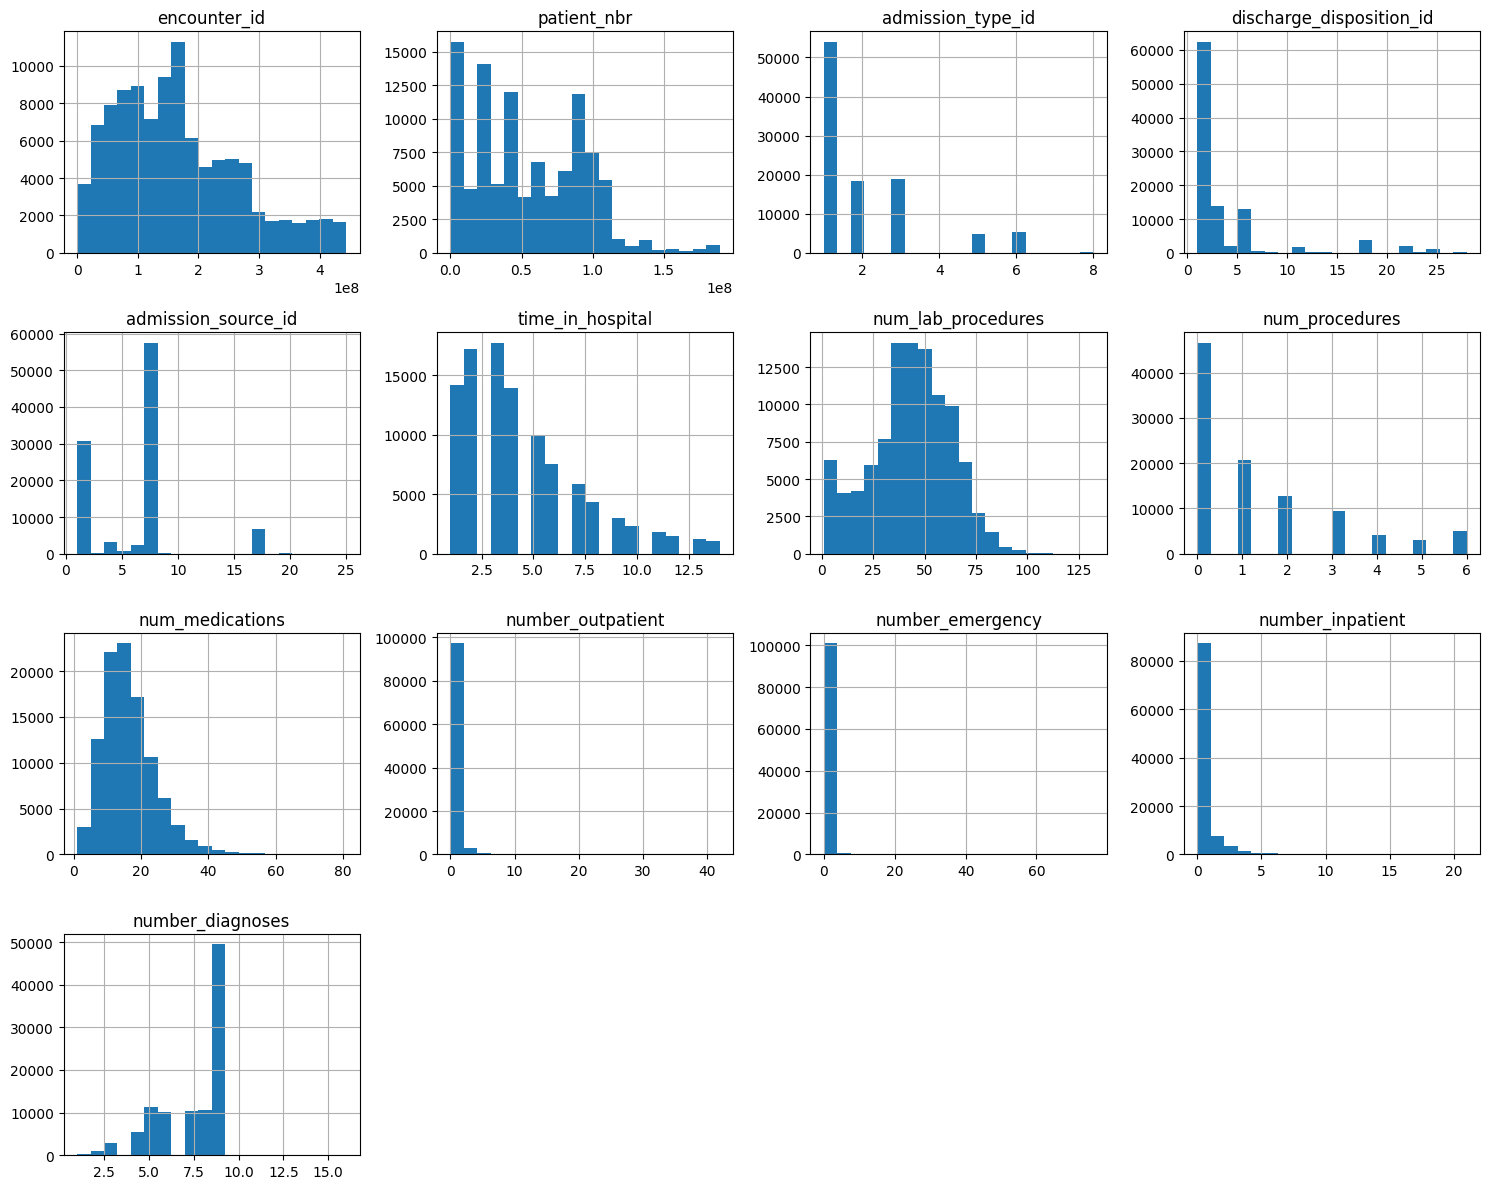

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 12))
df[numeric_cols].hist(figsize=(15, 12), bins=20)
plt.tight_layout()
plt.show()


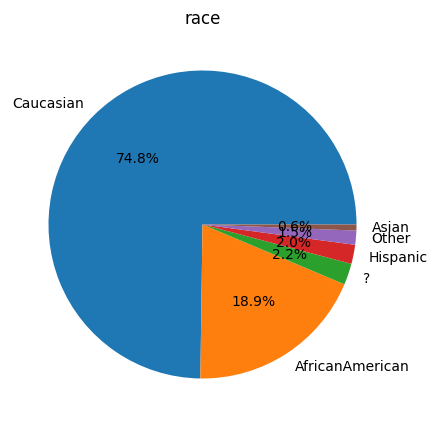

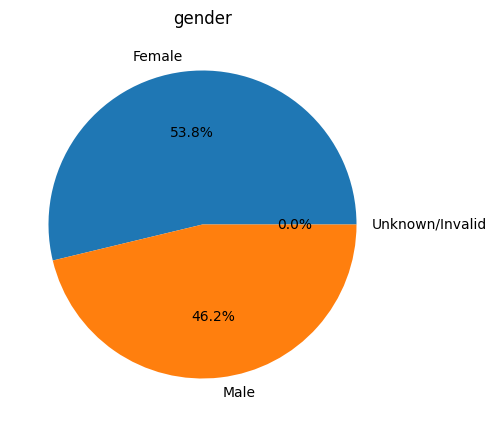

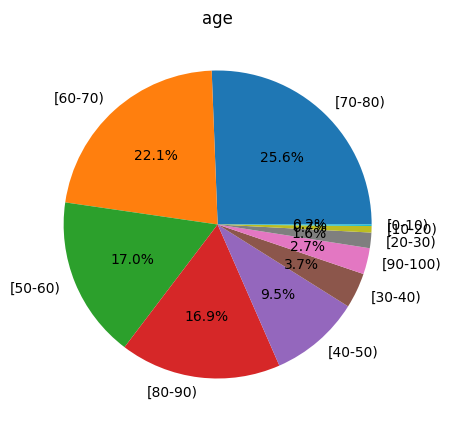

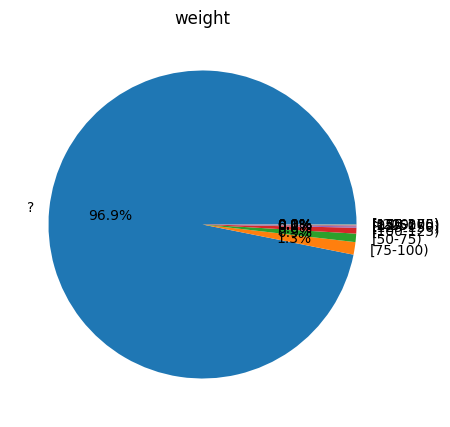

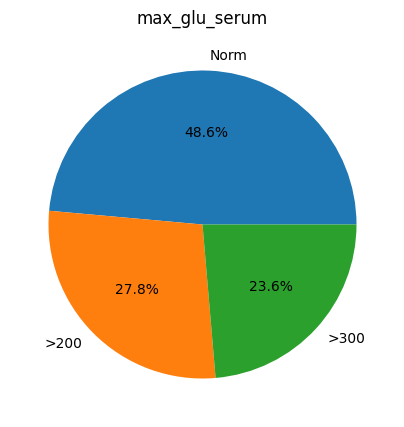

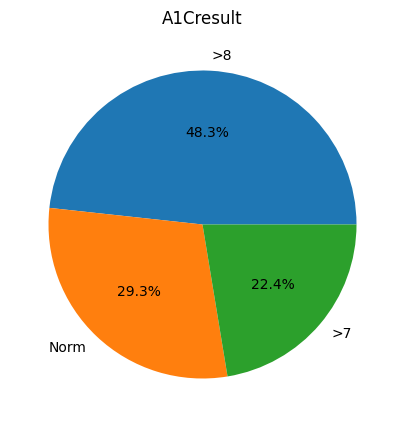

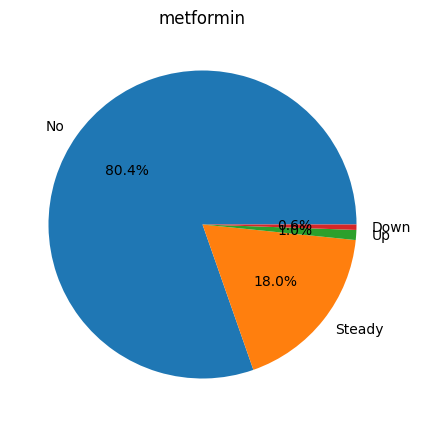

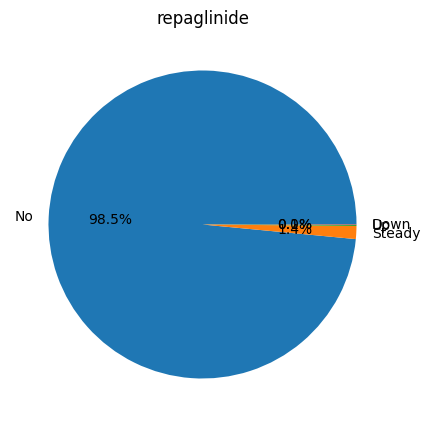

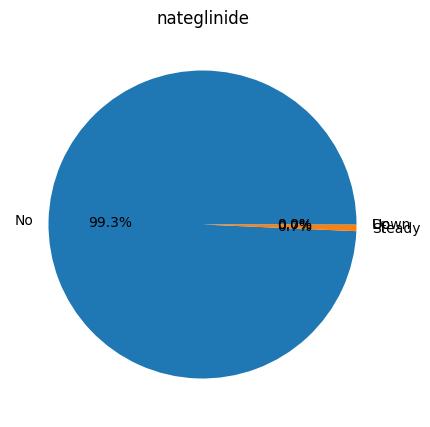

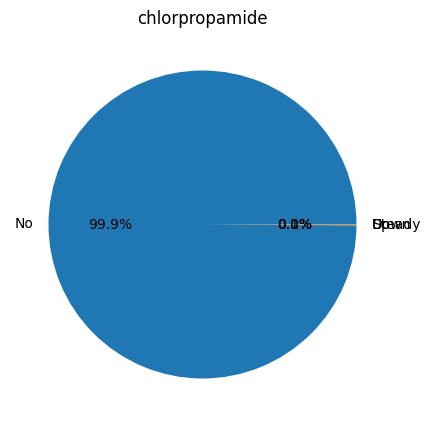

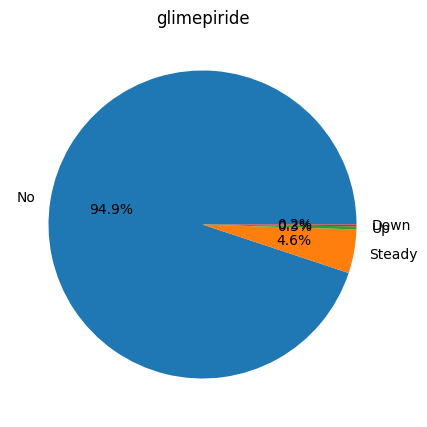

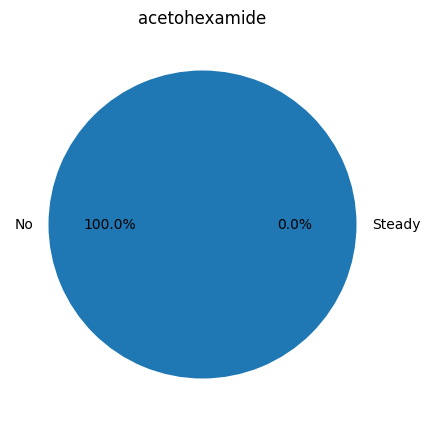

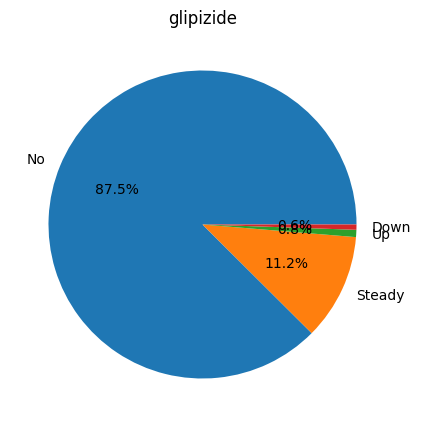

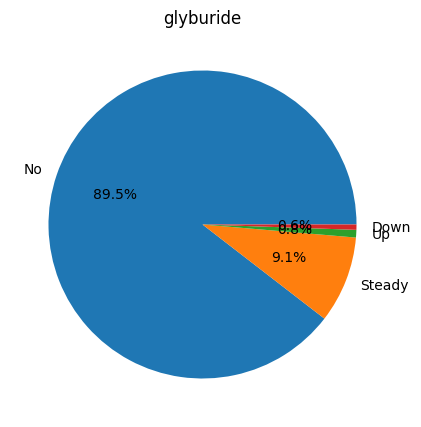

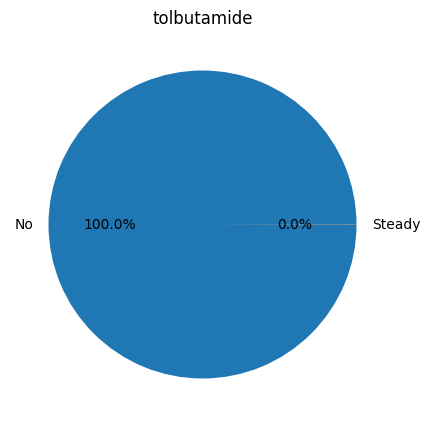

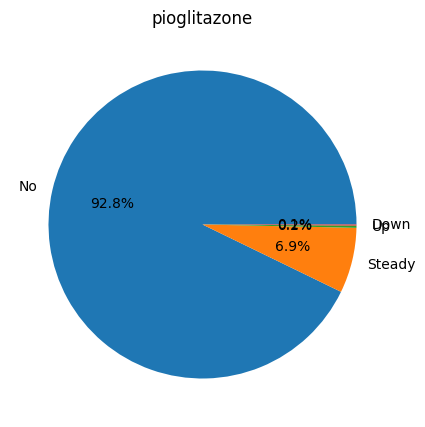

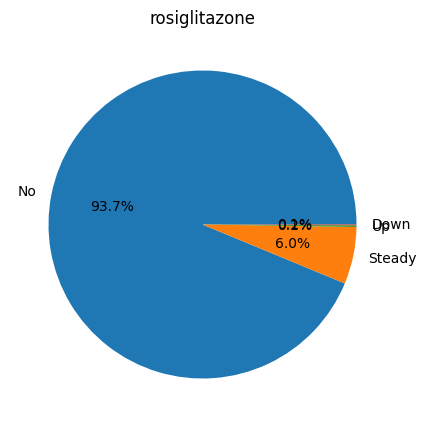

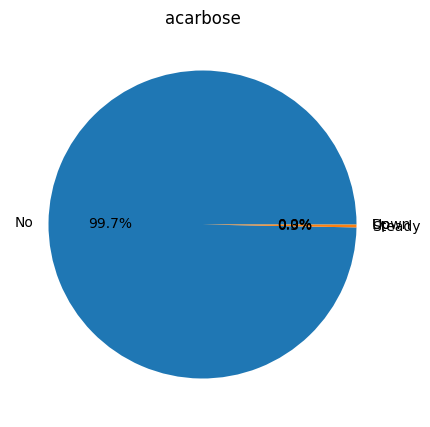

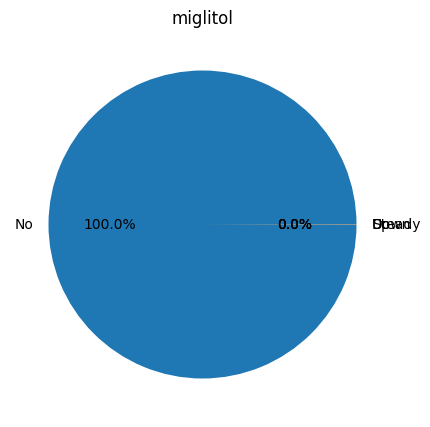

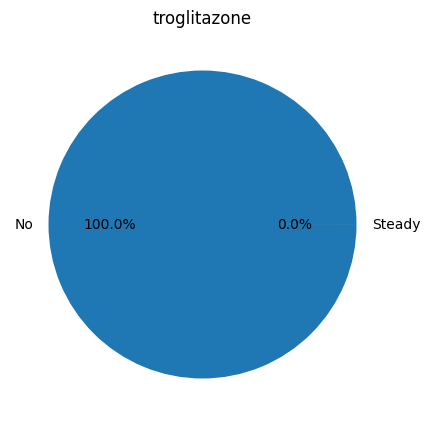

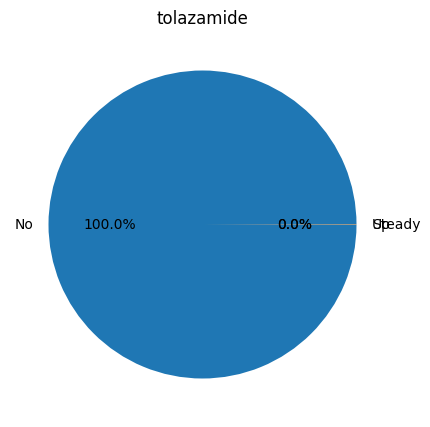

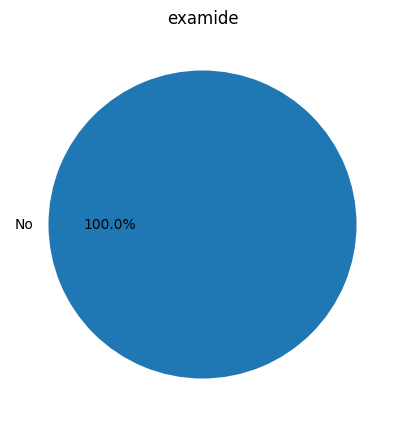

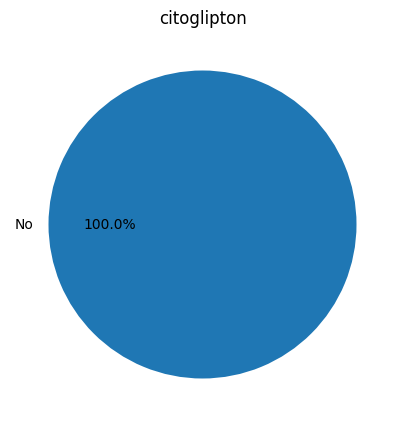

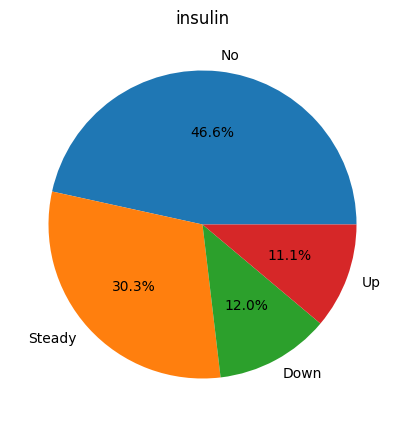

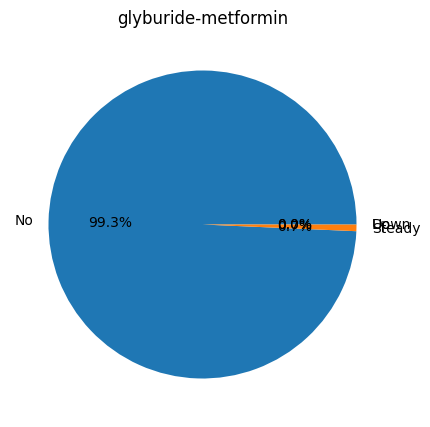

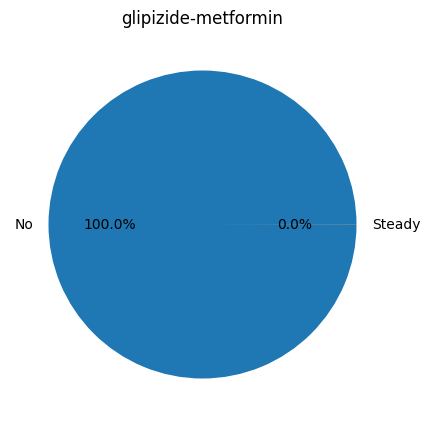

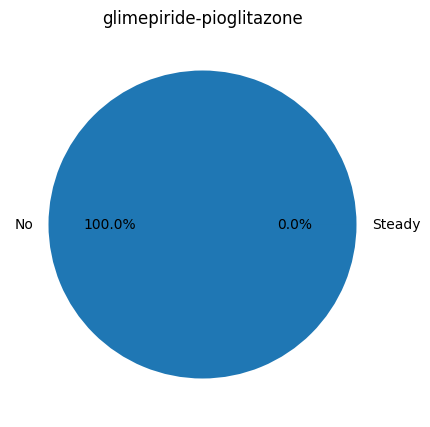

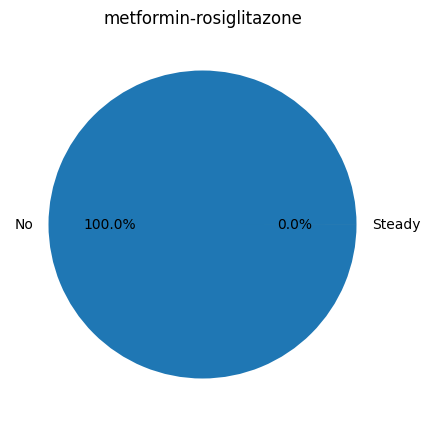

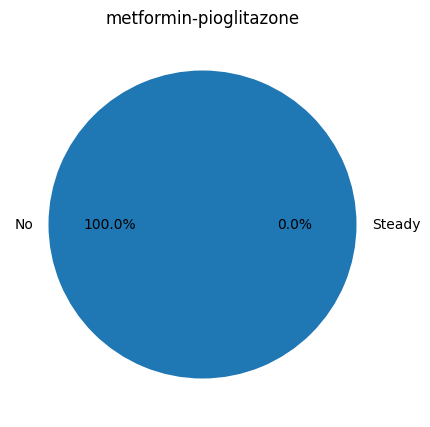

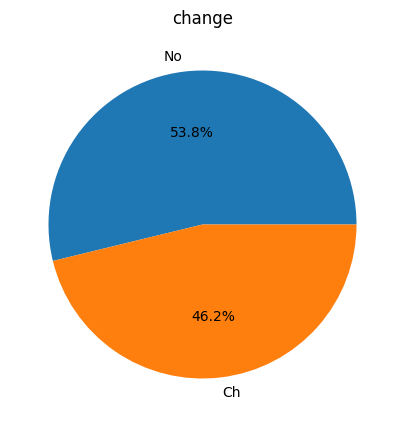

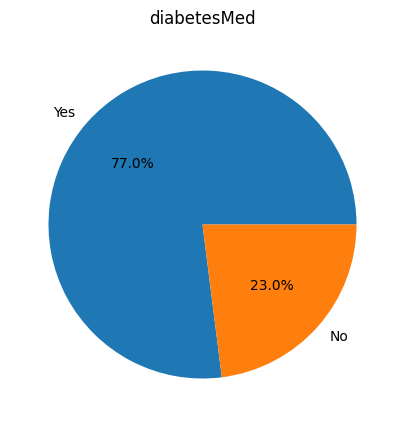

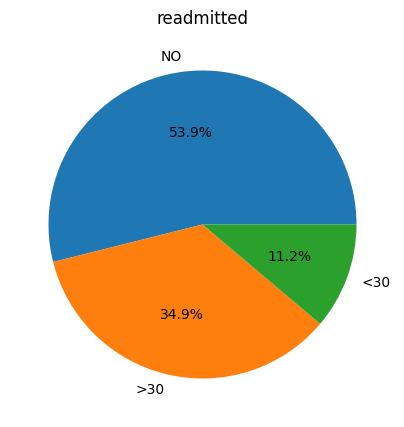

In [ ]:
for col in categorical_cols:
    if df[col].nunique() <= 10:
        plt.figure(figsize=(5,5))
        df[col].value_counts().plot(kind='pie', autopct='%1.1f%%')
        plt.title(col)
        plt.ylabel('')
        plt.show()


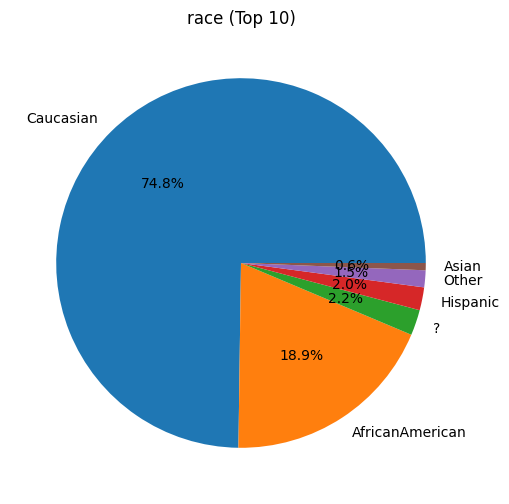

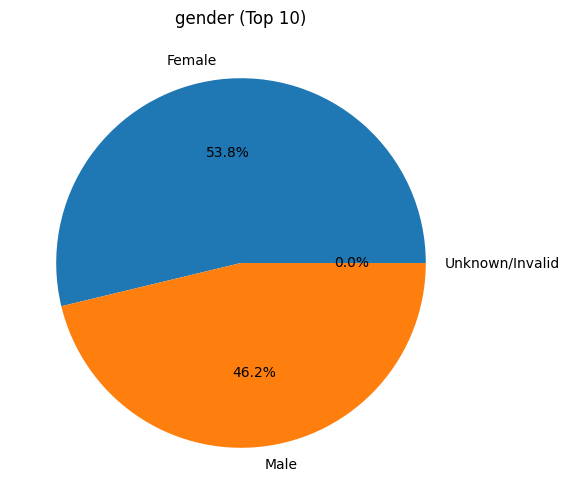

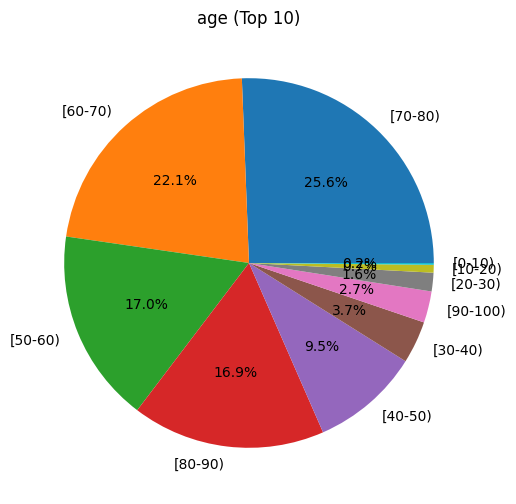

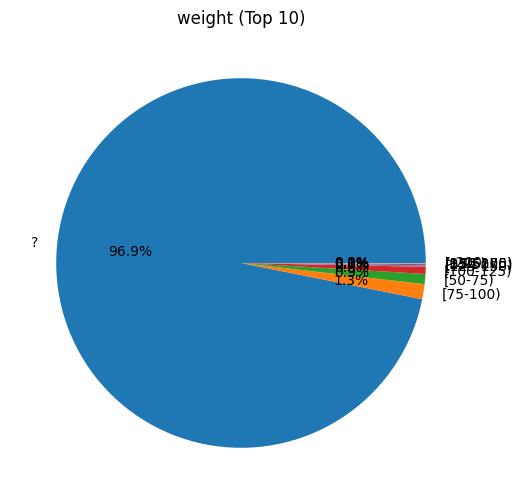

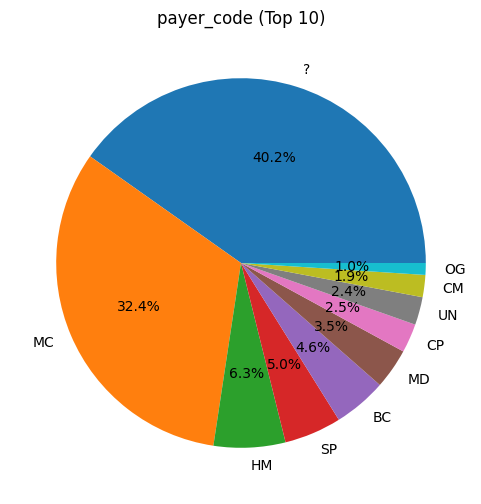

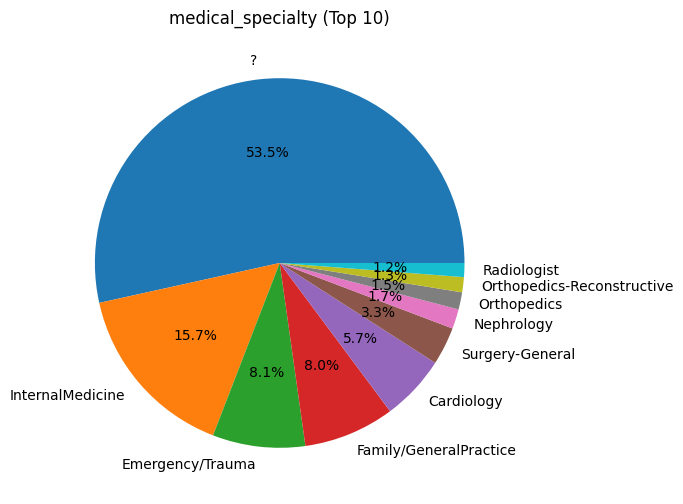

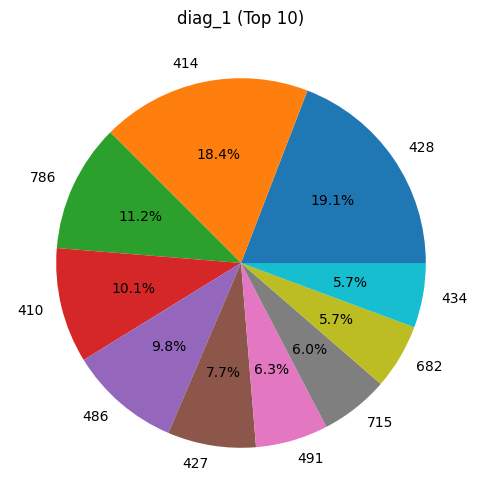

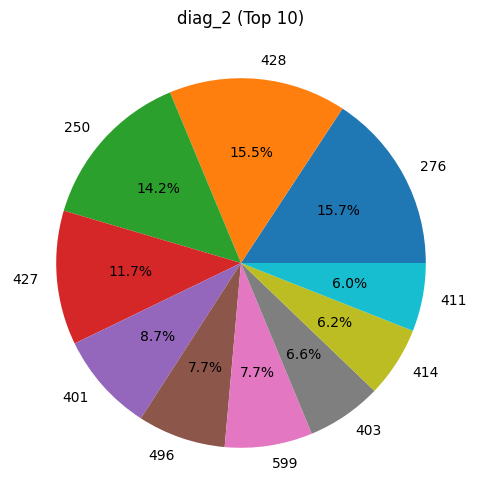

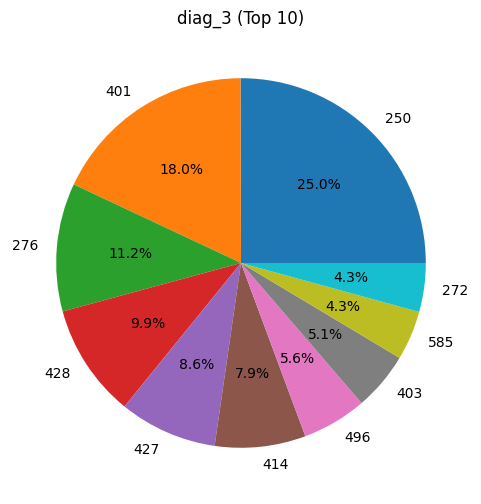

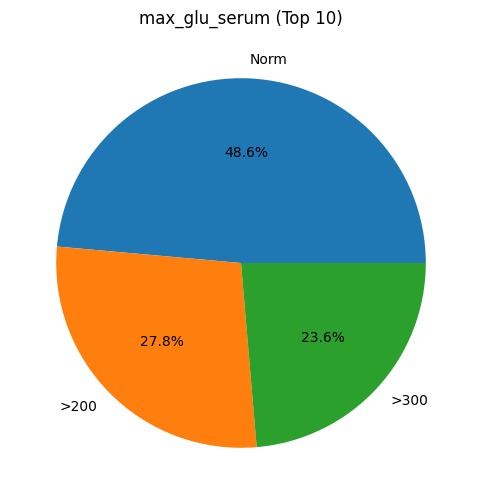

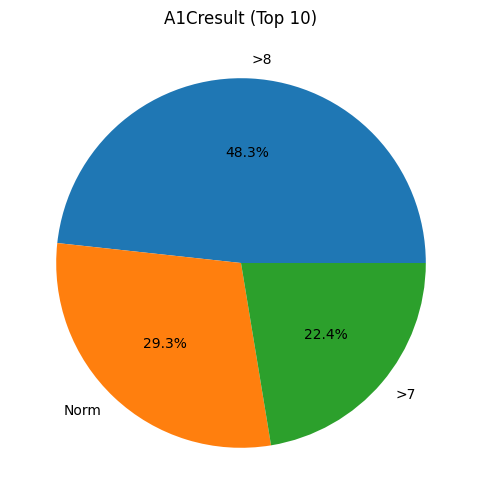

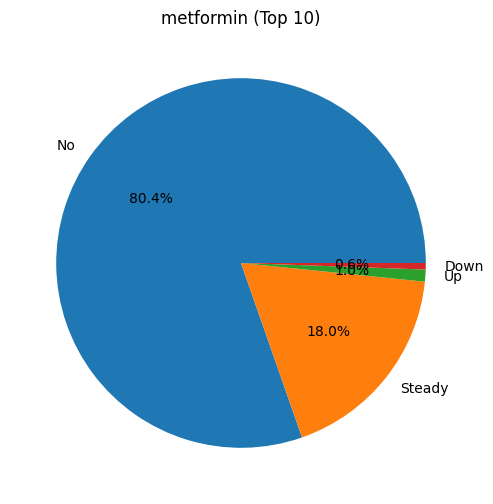

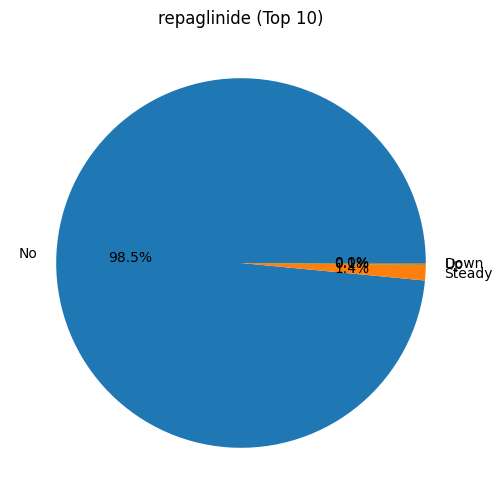

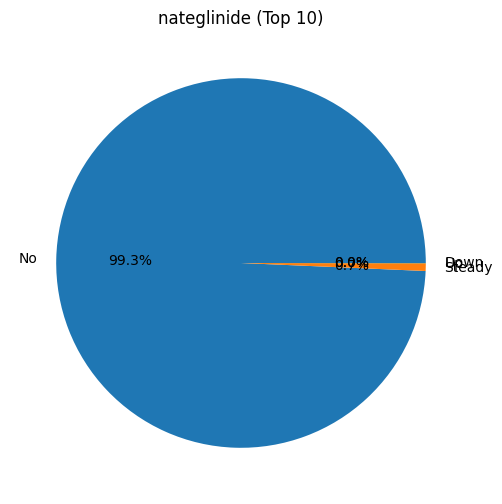

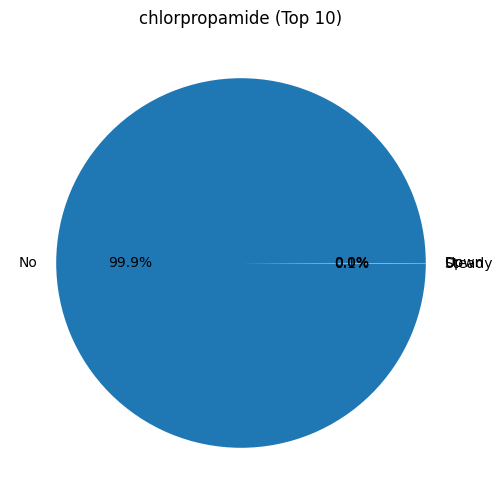

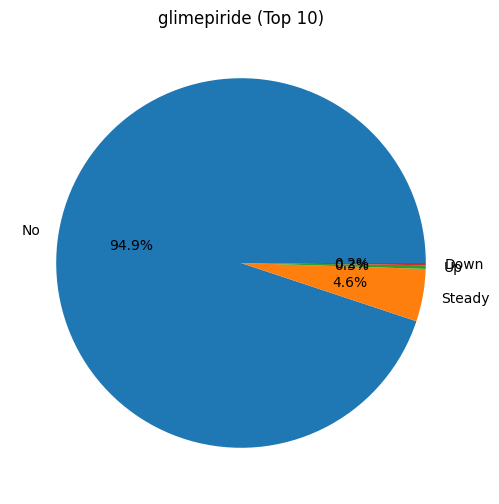

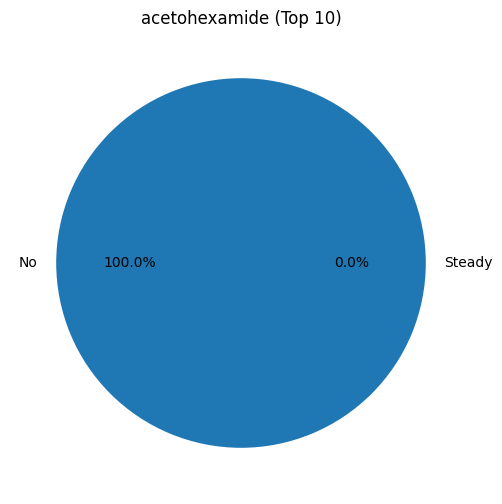

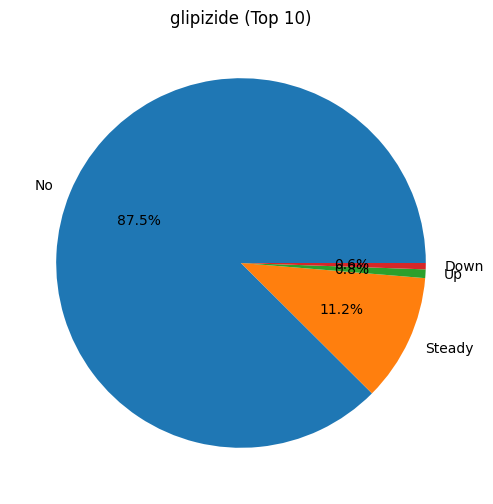

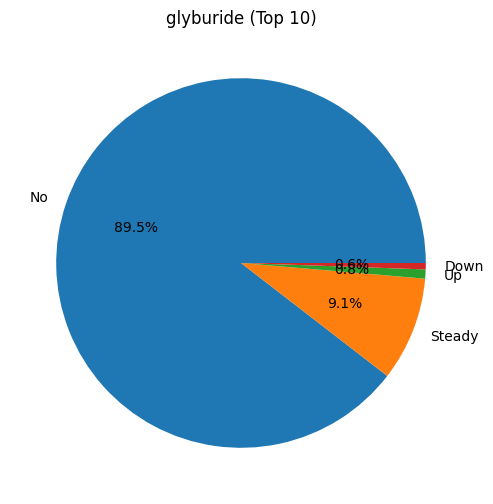

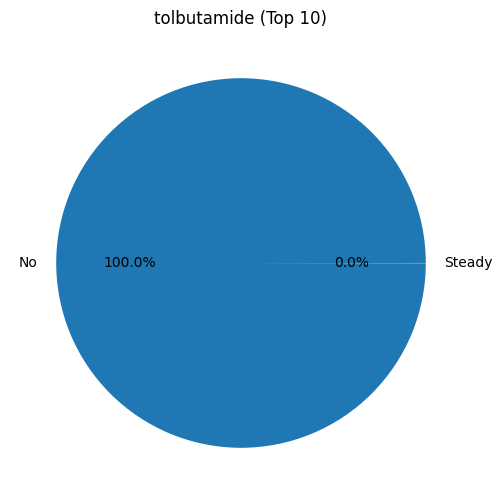

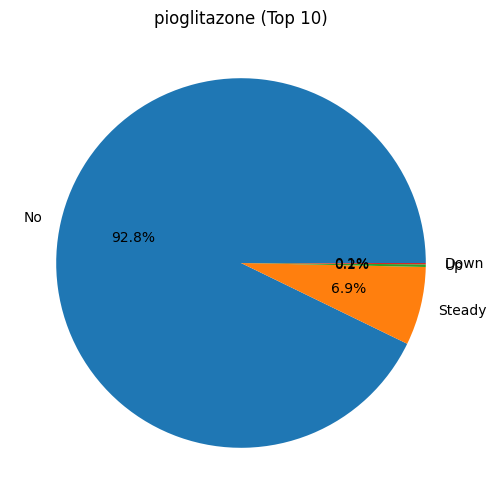

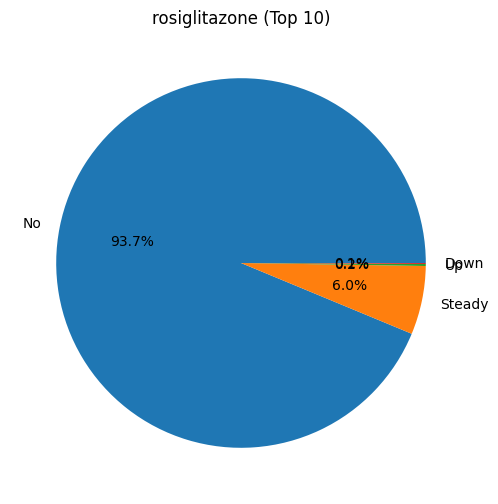

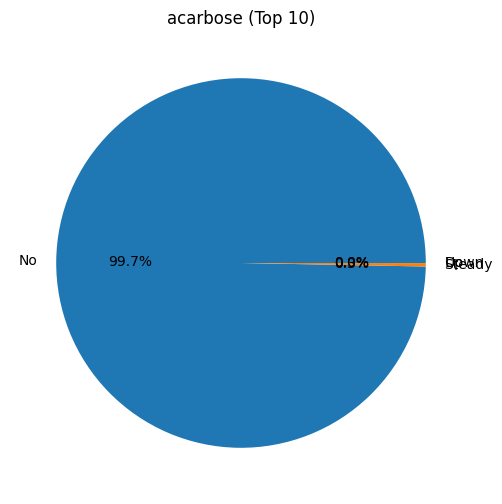

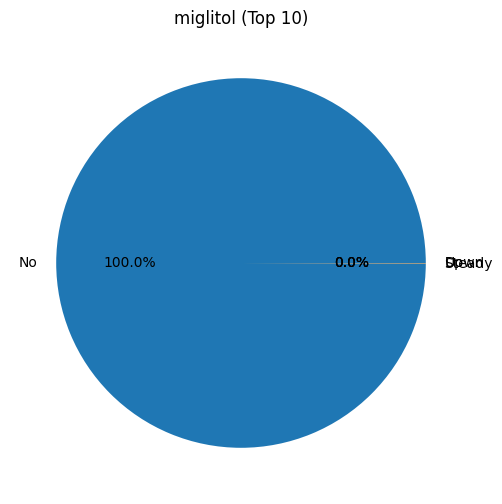

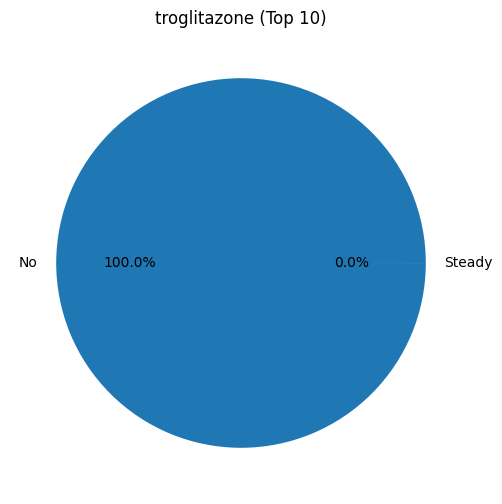

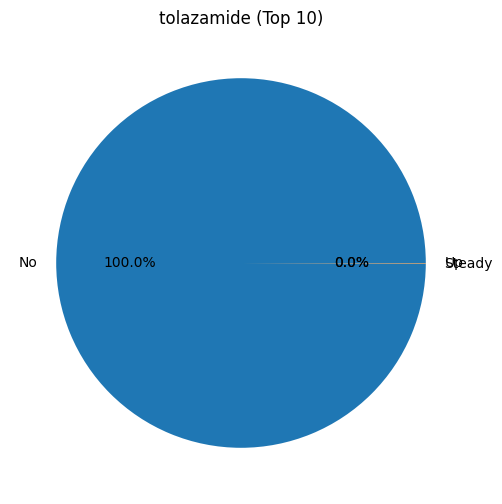

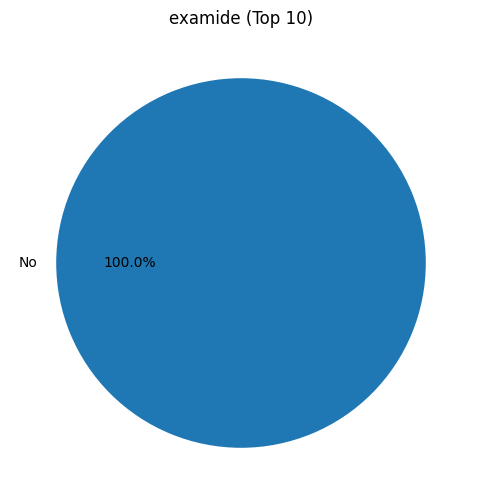

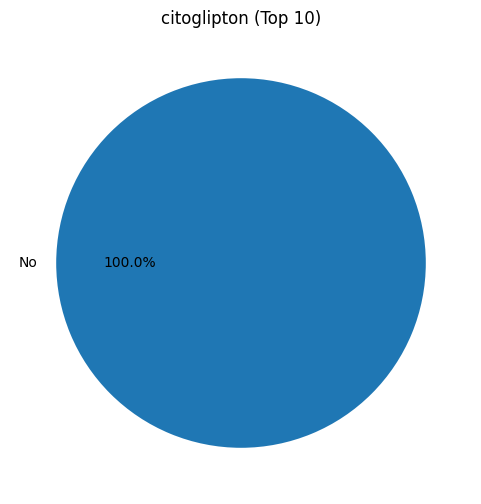

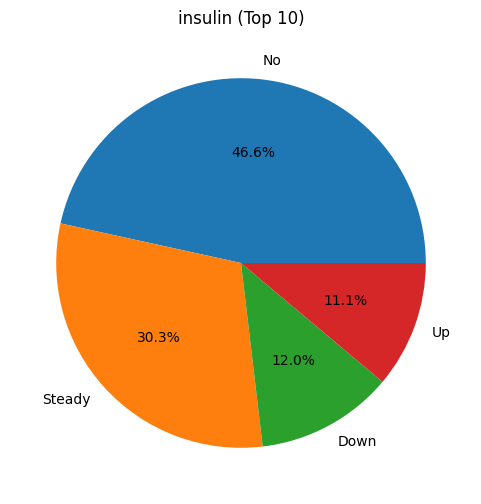

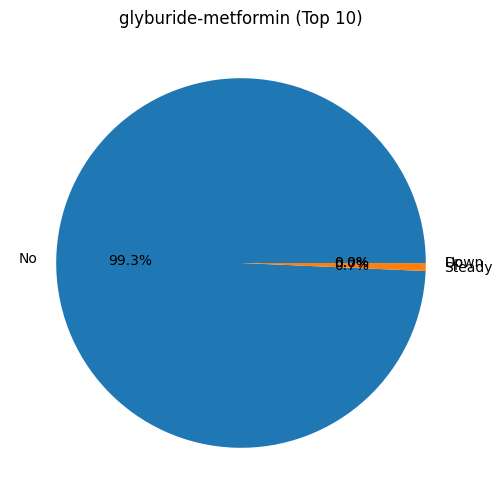

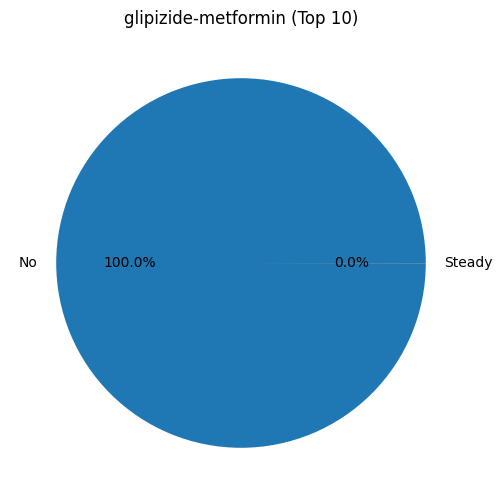

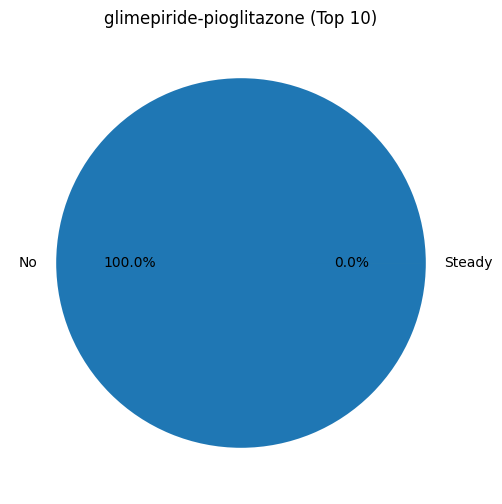

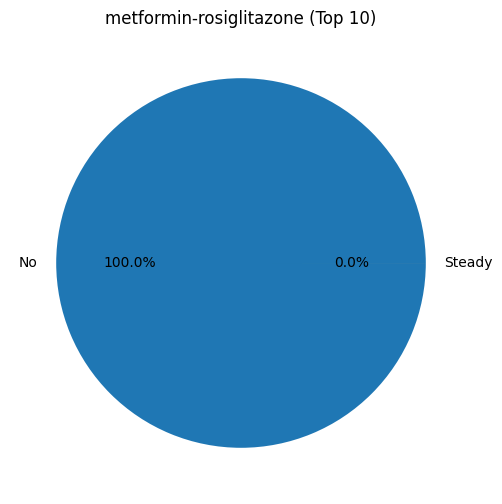

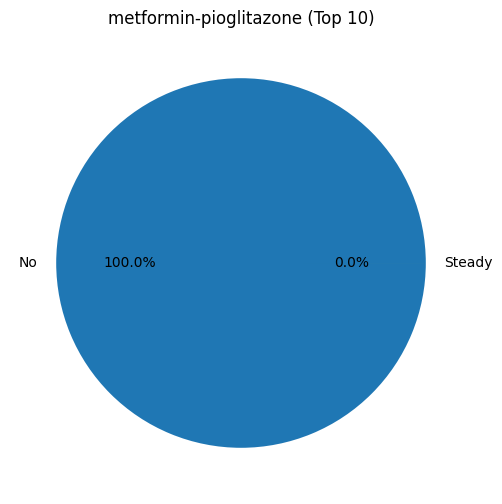

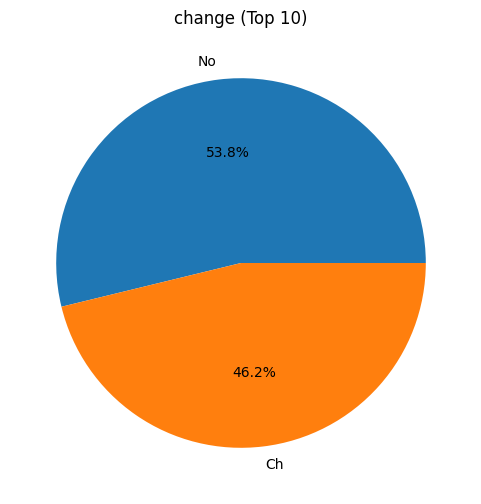

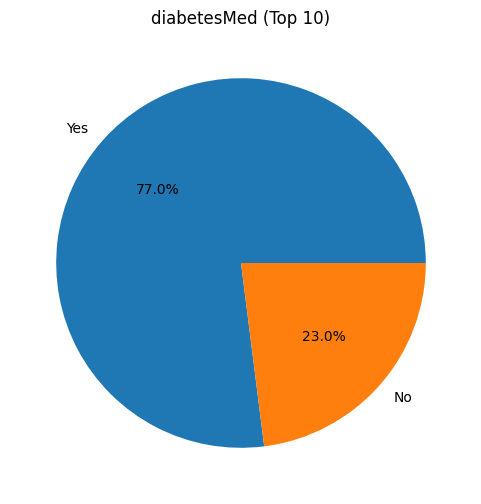

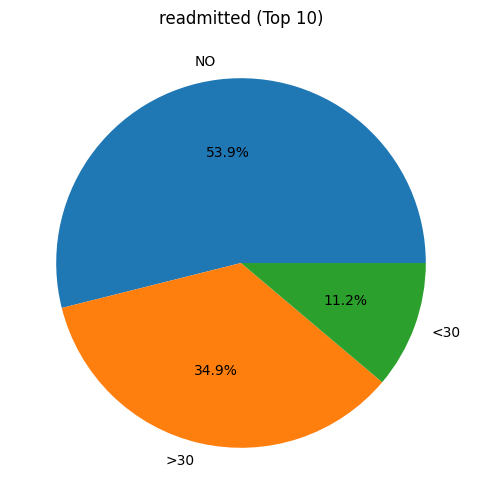

In [ ]:
for col in categorical_cols:
    plt.figure(figsize=(6,6))
    df[col].value_counts().head(10).plot(kind='pie', autopct='%1.1f%%')
    plt.title(col + " (Top 10)")
    plt.ylabel('')
    plt.show()
